# XSM: restore a fresh Colab session

Use a CPU runtime. No Google Drive mount or path editing is required. Run cells in order. This notebook restores the corrected **0.2.0** pipeline and the July 16 data you supplied.

The earlier September raw Level-1 inspection is not part of this workflow. The dataset has no reviewed event labels: this runs candidate detection, not supervised model training.


## 1. Upload the corrected package or your latest backup


In [1]:
from google.colab import files
from pathlib import Path
import tempfile, zipfile

# Select XSM_Hybrid_ML_Code.zip, or your latest XSM_work_backup.zip.
uploaded = files.upload()
packages = []
for name in uploaded:
    if zipfile.is_zipfile(name):
        with zipfile.ZipFile(name) as archive:
            if "xsm_hybrid_ml/run_xsm.py" in archive.namelist():
                packages.append(name)
if len(packages) != 1:
    raise ValueError("Select exactly one corrected code ZIP or project backup ZIP.")

workspace = Path(tempfile.mkdtemp(prefix="xsm_recovery_", dir="/content"))
with zipfile.ZipFile(packages[0]) as archive:
    for member in archive.infolist():
        target = (workspace / member.filename).resolve()
        if not target.is_relative_to(workspace.resolve()):
            raise ValueError("Unsafe ZIP path")
    archive.extractall(workspace)
PROJECT = workspace / "xsm_hybrid_ml"
print("Project restored:", PROJECT)
print("July input data and existing results are included.")


Saving XSM_Hybrid_ML_Code (2).zip to XSM_Hybrid_ML_Code (2).zip
Project restored: /content/xsm_recovery_buk02kky/xsm_hybrid_ml
July input data and existing results are included.


## 2. Install dependencies


In [2]:
import subprocess, sys

# Runs in a fresh Python process, so stale notebook imports are not used.
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-r",
    str(PROJECT / "requirements-tested.txt")
], check=True)
print("Dependencies installed. Continue to the next cell.")


Dependencies installed. Continue to the next cell.


## 3. Run the July observation


In [3]:
from datetime import datetime, timezone
import uuid

RUN = PROJECT / "runs" / (datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6])
subprocess.run([
    sys.executable, str(PROJECT / "run_xsm.py"),
    "--input", str(PROJECT / "data" / "july16"),
    "--out", str(RUN)
], check=True)


CompletedProcess(args=['/usr/bin/python3', '/content/xsm_recovery_buk02kky/xsm_hybrid_ml/run_xsm.py', '--input', '/content/xsm_recovery_buk02kky/xsm_hybrid_ml/data/july16', '--out', '/content/xsm_recovery_buk02kky/xsm_hybrid_ml/runs/20261009_092905_b53554'], returncode=0)

## 4. Review the candidates


candidate_id,observed_peak_s,duration_observed_s,peak_snr,quality_flags,label
733be91d8a_216cec93_0_0,749.5,3.0,3.533505470371899,no_improvement_over_linear_background;timescale_unresolved,
733be91d8a_216cec93_2_0,7427.5,1.0,3.832451936131715,insufficient_event_bins;single_bin_candidate,


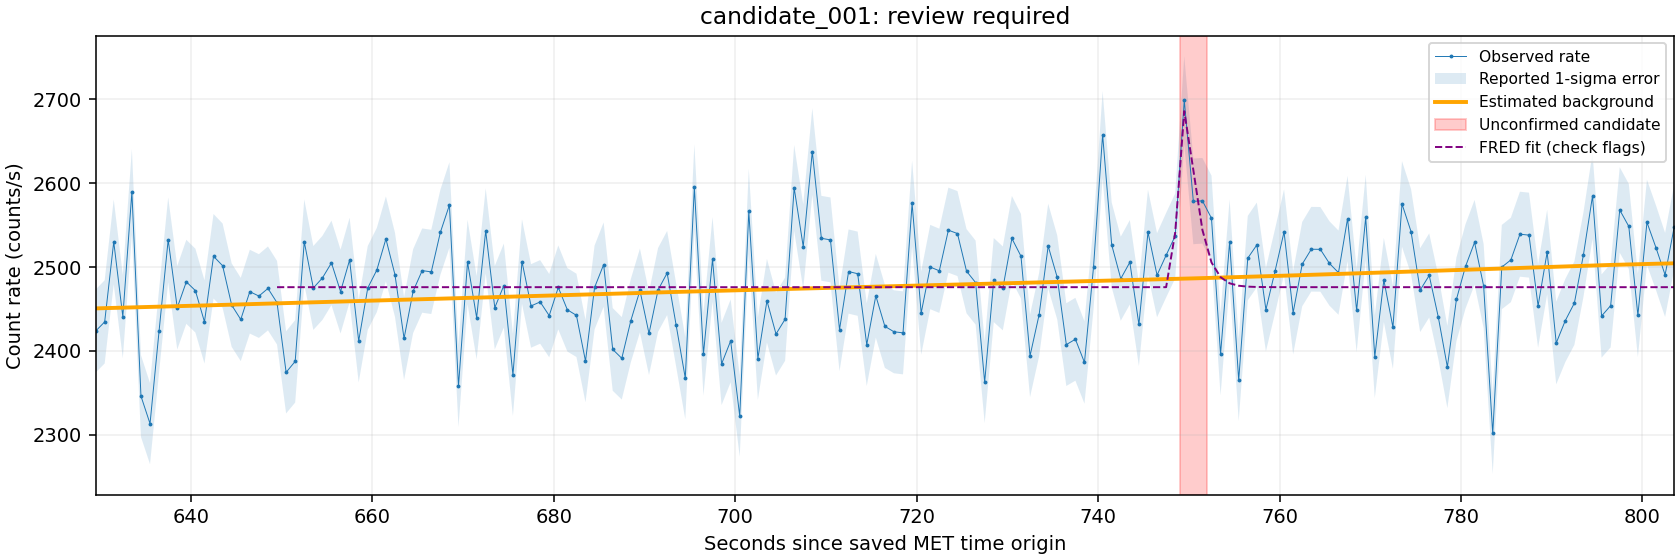

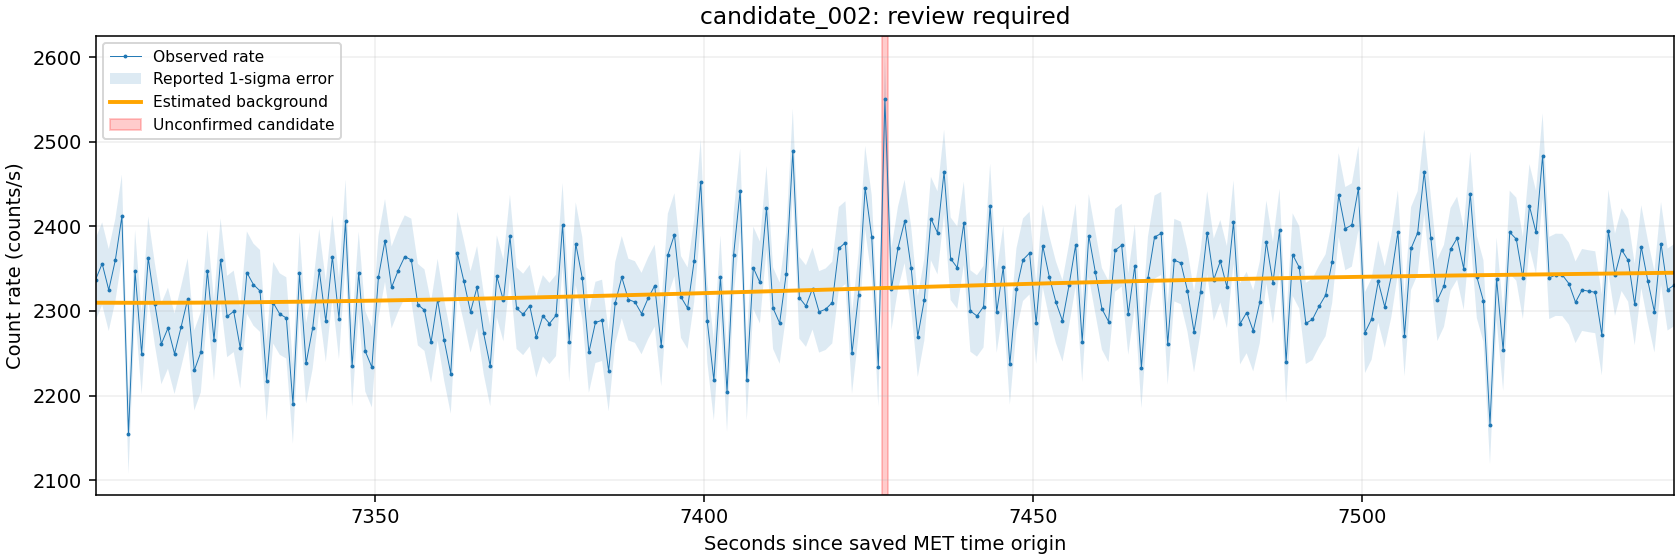

These are unconfirmed candidates. Labels remain blank.


In [4]:
# Display saved outputs without importing the engine into the notebook kernel.
from IPython.display import display, Image, HTML
import csv, html

for directory in sorted(RUN.iterdir()):
    if not directory.is_dir():
        continue
    with (directory / "review_candidates.csv").open() as stream:
        rows = list(csv.DictReader(stream))
    columns = ["candidate_id", "observed_peak_s", "duration_observed_s", "peak_snr", "quality_flags", "label"]
    table = "<table><tr>" + "".join("<th>" + html.escape(c) + "</th>" for c in columns) + "</tr>"
    for row in rows:
        table += "<tr>" + "".join("<td>" + html.escape(row[c]) + "</td>" for c in columns) + "</tr>"
    display(HTML(table + "</table>"))
    for plot in sorted((directory / "review_plots").glob("candidate_*.png"))[:5]:
        display(Image(filename=str(plot)))
print("These are unconfirmed candidates. Labels remain blank.")


## 5. Download a full backup before ending the session


In [5]:
import shutil
from google.colab import files

# Full project backup: code, input files, outputs and any labels you entered.
# Store the ZIP on your computer before ending the runtime.
backup_path = shutil.make_archive(
    "/content/XSM_work_backup", "zip",
    root_dir=PROJECT.parent, base_dir=PROJECT.name
)
files.download(backup_path)
print("Keep XSM_work_backup.zip on your computer. Use it in cell 1 after a reset.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Keep XSM_work_backup.zip on your computer. Use it in cell 1 after a reset.


In [6]:
from google.colab import files
from pathlib import Path
import zipfile
import tempfile

DATA_ROOT = PROJECT / "data" / "additional_days"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

uploaded = files.upload()

for name in uploaded:
    if not zipfile.is_zipfile(name):
        print("Skipping non-ZIP file:", name)
        continue

    destination = Path(tempfile.mkdtemp(
        prefix="dataset_", dir=str(DATA_ROOT)
    ))

    with zipfile.ZipFile(name) as archive:
        for member in archive.infolist():
            # Extract light curves, GTIs and metadata.
            # The large raw Level-1 files are unnecessary here.
            if member.is_dir():
                continue
            if not member.filename.lower().endswith((".lc", ".gti", ".xml")):
                continue

            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination.resolve()):
                raise ValueError("Unsafe ZIP path")

            archive.extract(member, destination)

print("Available light curves:")
for path in sorted(DATA_ROOT.rglob("*.lc")):
    print(path.relative_to(DATA_ROOT))

Saving ch2_xsm_20260910_v1.zip to ch2_xsm_20260910_v1.zip
Saving ch2_xsm_20260911_v1.zip to ch2_xsm_20260911_v1.zip
Saving ch2_xsm_20260912_v1.zip to ch2_xsm_20260912_v1.zip
Saving ch2_xsm_20260921_v1.zip to ch2_xsm_20260921_v1.zip
Saving ch2_xsm_20260913_v1.zip to ch2_xsm_20260913_v1.zip
Saving ch2_xsm_20260916_v1.zip to ch2_xsm_20260916_v1.zip
Saving ch2_xsm_20260917_v1.zip to ch2_xsm_20260917_v1.zip
Saving ch2_xsm_20260919_v1 (1).zip to ch2_xsm_20260919_v1 (1).zip
Saving ch2_xsm_20260920_v1.zip to ch2_xsm_20260920_v1.zip
Available light curves:
dataset_56t_3ers/xsm/data/2026/09/11/calibrated/ch2_xsm_20260911_v1_level2.lc
dataset_8zbjlzf2/xsm/data/2026/09/21/calibrated/ch2_xsm_20260921_v1_level2.lc
dataset_cra9v0vm/xsm/data/2026/09/10/calibrated/ch2_xsm_20260910_v1_level2.lc
dataset_df7nko82/xsm/data/2026/09/20/calibrated/ch2_xsm_20260920_v1_level2.lc
dataset_fjfc2l_6/xsm/data/2026/09/13/calibrated/ch2_xsm_20260913_v1_level2.lc
dataset_h0tjk74u/xsm/data/2026/09/16/calibrated/ch2_xsm_

In [3]:
import subprocess
import sys
import uuid

BATCH_RUN = PROJECT / "runs" / f"batch_{uuid.uuid4().hex[:8]}"

subprocess.run([
    sys.executable,
    str(PROJECT / "run_xsm.py"),
    "--input", str(DATA_ROOT),
    "--out", str(BATCH_RUN),
], check=True)

print("Results saved in:", BATCH_RUN)

KeyboardInterrupt: 

In [2]:
from pathlib import Path

# Find the project extracted by the recovery notebook.
projects = [
    p for p in Path("/content").glob("xsm_recovery_*/xsm_hybrid_ml")
    if (p / "run_xsm.py").exists()
]

if not projects:
    raise RuntimeError(
        "Project files are missing. Run the recovery notebook's "
        "first upload/extraction cell and its dependency-installation cell."
    )

# Prefer a project containing your additional uploaded datasets.
with_data = [
    p for p in projects
    if any((p / "data" / "additional_days").rglob("*.lc"))
]

if len(with_data) > 1:
    raise RuntimeError(
        "Multiple projects contain datasets. Paste this list here:\n"
        + "\n".join(str(p) for p in with_data)
    )

PROJECT = with_data[0] if with_data else max(
    projects, key=lambda p: p.stat().st_mtime
)
DATA_ROOT = PROJECT / "data" / "additional_days"

print("Project:", PROJECT)
print("Additional light curves:", len(list(DATA_ROOT.rglob("*.lc"))))

Project: /content/xsm_recovery_buk02kky/xsm_hybrid_ml
Additional light curves: 9


In [5]:
import subprocess
import sys
import uuid

BATCH_RUN = PROJECT / "runs" / f"batch_{uuid.uuid4().hex[:8]}"

subprocess.run([
    sys.executable,
    str(PROJECT / "run_xsm.py"),
    "--input", str(DATA_ROOT),
    "--out", str(BATCH_RUN),
], check=True)

print("Results saved in:", BATCH_RUN)

KeyboardInterrupt: 

In [6]:
from google.colab import files
from pathlib import Path
import tempfile
import zipfile

uploaded = files.upload()
packages = []

for name in uploaded:
    if zipfile.is_zipfile(name):
        with zipfile.ZipFile(name) as archive:
            if "xsm_hybrid_ml/run_xsm.py" in archive.namelist():
                packages.append(name)

if len(packages) != 1:
    raise ValueError("Upload exactly one updated project ZIP or backup ZIP.")

workspace = Path(tempfile.mkdtemp(
    prefix="xsm_recovery_", dir="/content"
))

with zipfile.ZipFile(packages[0]) as archive:
    for member in archive.infolist():
        target = (workspace / member.filename).resolve()
        if not target.is_relative_to(workspace.resolve()):
            raise ValueError("Unsafe ZIP path")
    archive.extractall(workspace)

PROJECT = workspace / "xsm_hybrid_ml"
DATA_ROOT = PROJECT / "data"

print("Project restored:", PROJECT)

Saving XSM_work_backup.zip to XSM_work_backup (1).zip
Project restored: /content/xsm_recovery_pbfv15v8/xsm_hybrid_ml


In [7]:
import subprocess
import sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "-r", str(PROJECT / "requirements-tested.txt")
], check=True)

print("Installation complete.")

Installation complete.


In [8]:
uploaded = files.upload()

for name in uploaded:
    if not zipfile.is_zipfile(name):
        print("Skipped non-ZIP file:", name)
        continue

    destination = Path(tempfile.mkdtemp(
        prefix="observation_", dir=str(DATA_ROOT)
    ))

    with zipfile.ZipFile(name) as archive:
        for member in archive.infolist():
            if member.is_dir():
                continue

            if not member.filename.lower().endswith((".lc", ".gti", ".xml")):
                continue

            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination.resolve()):
                raise ValueError("Unsafe ZIP path")

            archive.extract(member, destination)

print("Available light curves:")
for path in sorted(DATA_ROOT.rglob("*.lc")):
    print(path.relative_to(DATA_ROOT))

Saving ch2_xsm_20260913_v1.zip to ch2_xsm_20260913_v1 (1).zip
Saving ch2_xsm_20260916_v1.zip to ch2_xsm_20260916_v1 (1).zip
Saving ch2_xsm_20260917_v1.zip to ch2_xsm_20260917_v1 (1).zip
Saving ch2_xsm_20260919_v1 (1).zip to ch2_xsm_20260919_v1 (1) (1).zip
Saving ch2_xsm_20260920_v1.zip to ch2_xsm_20260920_v1 (1).zip
Available light curves:
july16/ch2_xsm_20260716_v1_level2.lc
observation_5ubs85mp/xsm/data/2026/09/16/calibrated/ch2_xsm_20260916_v1_level2.lc
observation_6_iyfgen/xsm/data/2026/09/20/calibrated/ch2_xsm_20260920_v1_level2.lc
observation_6i6aglfv/xsm/data/2026/09/19/calibrated/ch2_xsm_20260919_v1_level2.lc
observation_8ayr2p9r/xsm/data/2026/09/17/calibrated/ch2_xsm_20260917_v1_level2.lc
observation_hiqt3qa4/xsm/data/2026/09/13/calibrated/ch2_xsm_20260913_v1_level2.lc


In [9]:
import hashlib
import re
import shutil
import uuid

sources = {}

for lc_file in sorted(DATA_ROOT.rglob("*.lc")):
    gti_file = lc_file.with_suffix(".gti")

    if not gti_file.exists():
        raise FileNotFoundError(f"Missing matching GTI: {gti_file}")

    match = re.search(r"_(\d{8})_", lc_file.name)
    if not match:
        raise ValueError(f"Cannot identify date: {lc_file.name}")

    day = match.group(1)
    signature = (
        hashlib.sha256(lc_file.read_bytes()).hexdigest(),
        hashlib.sha256(gti_file.read_bytes()).hexdigest(),
    )

    if day in sources:
        if sources[day][2] == signature:
            print("Skipping identical duplicate:", lc_file.name)
            continue
        raise ValueError(
            f"Different products found for {day}. "
            "Choose one LC/GTI version for that day."
        )

    sources[day] = (lc_file, gti_file, signature)

if not sources:
    raise RuntimeError("No light curves found. Check cell 3.")

run_id = uuid.uuid4().hex[:8]
prepared = PROJECT / "prepared_inputs" / run_id
prepared.mkdir(parents=True)

for day, (lc_file, gti_file, _) in sorted(sources.items()):
    folder = prepared / day
    folder.mkdir()
    shutil.copy2(lc_file, folder / lc_file.name)
    shutil.copy2(gti_file, folder / gti_file.name)

BATCH_RUN = PROJECT / "runs" / f"batch_{run_id}"

subprocess.run([
    sys.executable,
    str(PROJECT / "run_xsm.py"),
    "--input", str(prepared),
    "--out", str(BATCH_RUN),
], check=True)

print("Processing completed:", BATCH_RUN)

Processing completed: /content/xsm_recovery_pbfv15v8/xsm_hybrid_ml/runs/batch_60709243


In [10]:
import pandas as pd
import json

tables = []
observations = []

for folder in sorted(BATCH_RUN.iterdir()):
    if not folder.is_dir():
        continue

    candidate_file = folder / "review_candidates.csv"
    manifest_file = folder / "manifest.json"

    if not candidate_file.exists() or not manifest_file.exists():
        continue

    manifest = json.loads(manifest_file.read_text())
    source = manifest["metadata"]["source_file"]
    day = re.search(r"_(\d{8})_", source).group(1)

    table = pd.read_csv(candidate_file)
    table["group_id"] = day
    table = table.drop(columns=["split"], errors="ignore")
    tables.append(table)

    observations.append({
        "group_id": day,
        "source_file": source,
        "candidate_count": len(table),
        "processed_exposure_s": manifest["processed_exposure_s"],
        "split": "",
        "fully_reviewed": False,
    })

if not tables:
    raise RuntimeError("No completed results. Check cell 4.")

training_table = pd.concat(tables, ignore_index=True)
observation_table = pd.DataFrame(observations)

if training_table["candidate_id"].duplicated().any():
    raise ValueError("Duplicate candidate IDs found.")

# A new directory protects any previously edited review files.
review_folder = BATCH_RUN / f"training_review_{uuid.uuid4().hex[:8]}"
review_folder.mkdir()

candidate_path = review_folder / "training_candidates.csv"
observation_path = review_folder / "observation_groups.csv"

training_table.to_csv(candidate_path, index=False)
observation_table.to_csv(observation_path, index=False)

print("Observation days:", len(observation_table))
print("Total candidates:", len(training_table))
display(observation_table[["group_id", "candidate_count"]])

files.download(str(candidate_path))
files.download(str(observation_path))

Observation days: 6
Total candidates: 280


,group_id,candidate_count
0,20260716,2
1,20260913,65
2,20260916,26
3,20260917,37
4,20260919,96
5,20260920,54


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
backup_path = shutil.make_archive(
    "/content/XSM_work_backup",
    "zip",
    root_dir=PROJECT.parent,
    base_dir=PROJECT.name
)

files.download(backup_path)
print("Save this backup on your computer.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Save this backup on your computer.


In [12]:
from pathlib import Path
import sys, subprocess, io, zipfile
from google.colab import files

required = ["PROJECT", "BATCH_RUN", "review_folder"]
if any(name not in globals() for name in required):
    raise RuntimeError(
        "Notebook variables are missing. Restore your backup "
        "and run the existing setup cells first."
    )

PROJECT = Path(PROJECT)

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "ipywidgets>=8,<9"
])

uploaded = files.upload()
installed = False

for name, data in uploaded.items():
    if name.lower().endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            if "xsm_review_training.py" in archive.namelist():
                for member in ["xsm_review_training.py", "START_HERE.md"]:
                    (PROJECT / member).write_bytes(archive.read(member))
                installed = True

if not installed:
    raise RuntimeError("Please upload XSM_Review_Training_Addon.zip.")

print("Installed. Run the next cell.")

Saving XSM_Review_Training_Addon.zip to XSM_Review_Training_Addon.zip
Installed. Run the next cell.


In [13]:
from google.colab import output
output.enable_custom_widget_manager()

sys.path.insert(0, str(PROJECT))
from xsm_review_training import ReviewSession

review = ReviewSession(BATCH_RUN, review_folder)
review.status()
review.show()

decision    positive  negative  uncertain  unreviewed
split                                                
train              0         0          0         130
validation         0         0          0          96
test               0         0          0          54
Reviews saved in: /content/xsm_recovery_pbfv15v8/xsm_hybrid_ml/runs/batch_60709243/training_review_e7ece869/review_baseline/annotations.csv
Download a project backup after reviewing. Uncertain candidates are never assigned 0 automatically.


{'candidate': BoundedIntText(value=1, description='Candidate:', max=280, min=1),
 'reviewer': Text(value='', description='Reviewer:', placeholder='Name or initials'),
 'decision': Dropdown(description='Decision:', layout=Layout(width='460px'), options=(('Choose after review', 'unreviewed'), ('1: supported solar burst', 'positive'), ('0: supported non-burst', 'negative'), ('Uncertain / needs expert', 'uncertain')), value='unreviewed'),
 'evidence': Textarea(value='', description='Evidence:', layout=Layout(height='90px', width='95%'), placeholder='Reference event/time, expert judgement, or reason uncertain; no invented labels.'),
 'save': Button(button_style='success', description='Save and next', style=ButtonStyle())}

In [15]:
review.status()
print("\n".join(review.readiness()) or "Ready for training.")

decision    positive  negative  uncertain  unreviewed
split                                                
train              0         0          1         129
validation         0         0          0          96
test               0         0          0          54
Reviews saved in: /content/xsm_recovery_pbfv15v8/xsm_hybrid_ml/runs/batch_60709243/training_review_e7ece869/review_baseline/annotations.csv
Download a project backup after reviewing. Uncertain candidates are never assigned 0 automatically.
train: 129 candidates still unreviewed
train: need at least 5 independently reviewed examples of EACH class
validation: 96 candidates still unreviewed
validation: need at least 2 independently reviewed examples of EACH class
test: 54 candidates still unreviewed
test: need at least 2 independently reviewed examples of EACH class


In [16]:
from pathlib import Path
from datetime import datetime
from google.colab import files
import shutil

PROJECT = Path(PROJECT)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

backup_path = shutil.make_archive(
    f"/content/XSM_work_backup_{stamp}",
    "zip",
    root_dir=str(PROJECT.parent),
    base_dir=PROJECT.name
)

print("Backup created. Starting download...")
files.download(backup_path)

Backup created. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
review.show()

{'candidate': BoundedIntText(value=2, description='Candidate:', max=280, min=1),
 'reviewer': Text(value='', description='Reviewer:', placeholder='Name or initials'),
 'decision': Dropdown(description='Decision:', layout=Layout(width='460px'), options=(('Choose after review', 'unreviewed'), ('1: supported solar burst', 'positive'), ('0: supported non-burst', 'negative'), ('Uncertain / needs expert', 'uncertain')), value='unreviewed'),
 'evidence': Textarea(value='', description='Evidence:', layout=Layout(height='90px', width='95%'), placeholder='Reference event/time, expert judgement, or reason uncertain; no invented labels.'),
 'save': Button(button_style='success', description='Save and next', style=ButtonStyle())}

In [18]:
problems = review.readiness()

if problems:
    print("\n".join(problems))
else:
    print("Ready for training.")

train: 128 candidates still unreviewed
train: need at least 5 independently reviewed examples of EACH class
validation: 96 candidates still unreviewed
validation: need at least 2 independently reviewed examples of EACH class
test: 54 candidates still unreviewed
test: need at least 2 independently reviewed examples of EACH class


In [19]:
model_folder = review.train()

ValueError: Training is not ready:
- train: 128 candidates still unreviewed
- train: need at least 5 independently reviewed examples of EACH class
- validation: 96 candidates still unreviewed
- validation: need at least 2 independently reviewed examples of EACH class
- test: 54 candidates still unreviewed
- test: need at least 2 independently reviewed examples of EACH class
Do not invent labels to bypass these checks.

In [20]:
import numpy as np
import pandas as pd
from xsm_review_training import FEATURES, SPLIT_PLAN

if "review" not in globals():
    raise RuntimeError("Run the cell that creates 'review' first.")

demo_data = review.frame.copy()
demo_data["split"] = (
    demo_data["group_id"].astype(str).map(SPLIT_PLAN)
)

if demo_data["split"].isna().any():
    raise ValueError("An observation date is missing from the split plan.")

X = demo_data[FEATURES].apply(
    pd.to_numeric, errors="raise"
).replace([np.inf, -np.inf], np.nan)

train_mask = demo_data["split"].eq("train")

# Determine usable features from training data only.
feature_columns = X.columns[
    X.loc[train_mask].notna().any()
].tolist()

X = X[feature_columns]

print("Candidates by split:")
print(demo_data["split"].value_counts())
print("Usable features:", len(feature_columns))

Candidates by split:
split
train         130
validation     96
test           54
Name: count, dtype: int64
Usable features: 28


In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

anomaly_model = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination="auto",
        random_state=42,
        n_jobs=2
    )
)

anomaly_model.fit(X.loc[train_mask])

# Negate scores so larger values mean more unusual.
training_scores = -anomaly_model.score_samples(
    X.loc[train_mask]
)

# Demonstration review threshold—not a validated burst threshold.
review_threshold = float(
    np.quantile(training_scores, 0.95)
)

print("Training completed.")
print("Review threshold:", review_threshold)

Training completed.
Review threshold: 0.5623955248658769


,candidates,high_priority
split,,
train,130,7
validation,96,13
test,54,10


Highest-ranked candidates from the test day:


,candidate_id,group_id,observed_peak_s,anomaly_score,high_priority
260,7d948bb81e_216cec93_14_3,20260920,65417.5,0.688960,True
271,7d948bb81e_216cec93_16_7,20260920,81136.5,0.683279,True
270,7d948bb81e_216cec93_16_6,20260920,80937.5,0.682798,True
239,7d948bb81e_216cec93_5_3,20260920,23838.5,0.609477,True
259,7d948bb81e_216cec93_14_2,20260920,64910.5,0.587839,True
268,7d948bb81e_216cec93_16_4,20260920,80242.5,0.586035,True
261,7d948bb81e_216cec93_14_4,20260920,66396.5,0.586002,True
258,7d948bb81e_216cec93_14_1,20260920,62960.5,0.570768,True
269,7d948bb81e_216cec93_16_5,20260920,80628.5,0.567166,True
228,7d948bb81e_216cec93_1_2,20260920,1569.5,0.566280,True


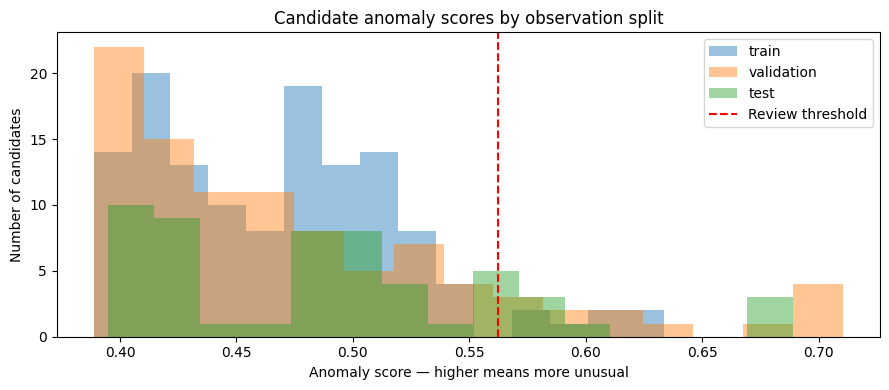

In [22]:
import matplotlib.pyplot as plt
from IPython.display import display

demo_data["anomaly_score"] = (
    -anomaly_model.score_samples(X)
)

demo_data["high_priority"] = (
    demo_data["anomaly_score"] >= review_threshold
)

summary = (
    demo_data.groupby("split")
    .agg(
        candidates=("candidate_id", "size"),
        high_priority=("high_priority", "sum")
    )
    .reindex(["train", "validation", "test"])
)

display(summary)

print("Highest-ranked candidates from the test day:")

display(
    demo_data.loc[demo_data["split"].eq("test")]
    .sort_values("anomaly_score", ascending=False)
    [[
        "candidate_id",
        "group_id",
        "observed_peak_s",
        "anomaly_score",
        "high_priority"
    ]]
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 4))

for split in ["train", "validation", "test"]:
    values = demo_data.loc[
        demo_data["split"].eq(split), "anomaly_score"
    ]
    ax.hist(values, bins=15, alpha=0.45, label=split)

ax.axvline(
    review_threshold,
    color="red",
    linestyle="--",
    label="Review threshold"
)

ax.set(
    title="Candidate anomaly scores by observation split",
    xlabel="Anomaly score — higher means more unusual",
    ylabel="Number of candidates"
)
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path
from datetime import datetime
from google.colab import files
import joblib
import json
import shutil
import sklearn

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

demo_folder = (
    Path(PROJECT) / "runs" / f"anomaly_demo_{stamp}"
)
demo_folder.mkdir(parents=True, exist_ok=False)

metadata = {
    "model_type": "IsolationForest",
    "purpose": "Unsupervised candidate ranking",
    "feature_columns": feature_columns,
    "review_threshold": review_threshold,
    "threshold_rule": "95th percentile of training anomaly scores",
    "split_plan": SPLIT_PLAN,
    "sklearn_version": sklearn.__version__,
    "compatibility": {
        key: str(demo_data[key].iloc[0])
        for key in [
            "pipeline_hash", "feature_version", "quantity", "unit"
        ]
    },
    "limitations": [
        "No confirmed event labels used.",
        "Scores are not burst probabilities.",
        "Classification accuracy is unknown.",
        "Only extracted candidates are ranked."
    ]
}

joblib.dump(
    {"model": anomaly_model, "metadata": metadata},
    demo_folder / "anomaly_model.joblib"
)

demo_data.to_csv(
    demo_folder / "ranked_candidates.csv", index=False
)
summary.to_csv(demo_folder / "split_summary.csv")

(demo_folder / "model_info.json").write_text(
    json.dumps(metadata, indent=2)
)

fig.savefig(
    demo_folder / "anomaly_scores.png",
    dpi=150,
    bbox_inches="tight"
)

download_path = shutil.make_archive(
    f"/content/XSM_anomaly_demo_{stamp}",
    "zip",
    root_dir=str(demo_folder.parent),
    base_dir=demo_folder.name
)

files.download(download_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from pathlib import Path
from google.colab import files
import sys

required = [
    "PROJECT", "anomaly_model", "feature_columns",
    "review_threshold", "demo_data"
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier Isolation Forest cells first. Missing: "
        + ", ".join(missing)
    )

uploaded = files.upload()

names = [
    name for name in uploaded
    if name.startswith("xsm_simulation_check") and name.endswith(".py")
]

if len(names) != 1:
    raise RuntimeError("Upload the downloaded xsm_simulation_check.py file.")

helper_path = Path(PROJECT) / "xsm_simulation_check.py"
helper_path.write_bytes(uploaded[names[0]])

sys.path.insert(0, str(Path(PROJECT) / "src"))
sys.path.insert(0, str(PROJECT))

from xsm_simulation_check import run_simulation_check

print("Ready for the simulation test.")

Saving xsm_simulation_check.py to xsm_simulation_check.py
Ready for the simulation test.


Simulation 1/24 finished
Simulation 2/24 finished
Simulation 3/24 finished
Simulation 4/24 finished
Simulation 5/24 finished
Simulation 6/24 finished
Simulation 7/24 finished
Simulation 8/24 finished
Simulation 9/24 finished
Simulation 10/24 finished
Simulation 11/24 finished
Simulation 12/24 finished
Simulation 13/24 finished
Simulation 14/24 finished
Simulation 15/24 finished
Simulation 16/24 finished
Simulation 17/24 finished
Simulation 18/24 finished
Simulation 19/24 finished
Simulation 20/24 finished
Simulation 21/24 finished
Simulation 22/24 finished
Simulation 23/24 finished
Simulation 24/24 finished

Saved simulation outputs: /content/xsm_recovery_pbfv15v8/xsm_hybrid_ml/runs/simulation_check_20261009_124759

Recovery counts (do not interpret these as real-data accuracy):
          stage  strength  injected  recovered  missed  false_triggers  recovery_percent
     Extraction         3         4          4       0               9             100.0
     Extraction         5       

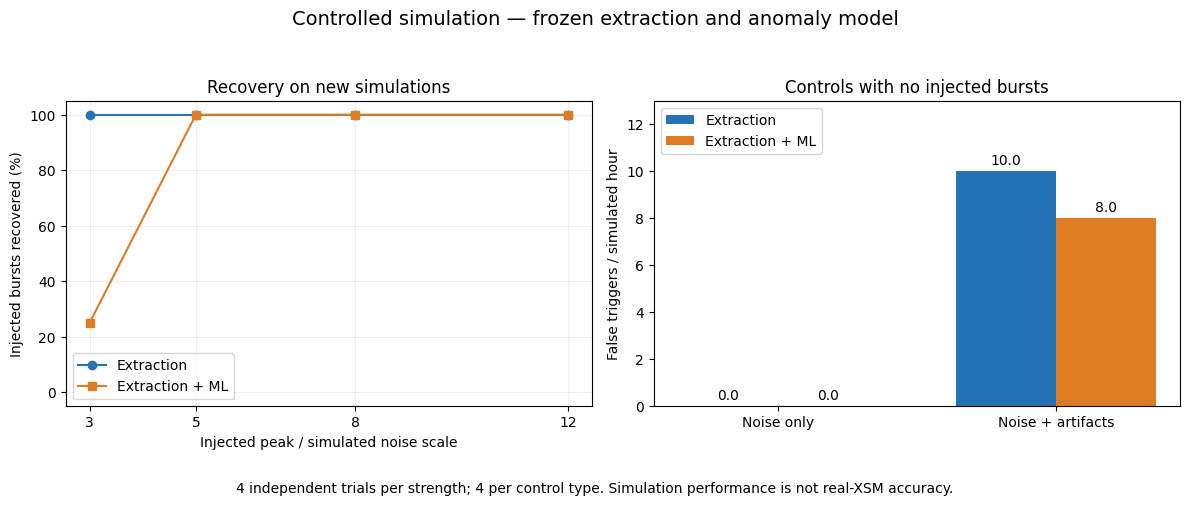

BURST RECOVERY


,stage,strength,injected,recovered,missed,false_triggers,recovery_percent
0,Extraction,3,4,4,0,9,100.0
1,Extraction,5,4,4,0,11,100.0
2,Extraction,8,4,4,0,11,100.0
3,Extraction,12,4,4,0,11,100.0
4,Extraction + ML,3,4,1,3,8,25.0
5,Extraction + ML,5,4,4,0,8,100.0
6,Extraction + ML,8,4,4,0,7,100.0
7,Extraction + ML,12,4,4,0,8,100.0


FALSE TRIGGERS ON SIGNALS WITH NO BURSTS


,stage,kind,false_triggers,processed_seconds,false_triggers_per_simulated_hour
0,Extraction,artifacts_only,10,3600.0,10.0
1,Extraction,noise_only,0,3600.0,0.0
2,Extraction + ML,artifacts_only,8,3600.0,8.0
3,Extraction + ML,noise_only,0,3600.0,0.0


In [26]:
from datetime import datetime
from IPython.display import display
import matplotlib.pyplot as plt

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

simulation_folder = (
    Path(PROJECT) / "runs" / f"simulation_check_{stamp}"
)

trial_results, recovery, controls, simulation_fig = (
    run_simulation_check(
        model=anomaly_model,
        feature_columns=feature_columns,
        threshold=review_threshold,
        frame=demo_data,
        output_dir=simulation_folder
    )
)

plt.show()

print("BURST RECOVERY")
display(recovery)

print("FALSE TRIGGERS ON SIGNALS WITH NO BURSTS")
display(controls)

SIMULATION METRICS (injected bursts = ground truth)


,stage,strength,injected,recovered,missed,false_triggers,precision,recall,f1
0,Extraction,3,4,4,0,9,0.308,1.00,0.471
1,Extraction,5,4,4,0,11,0.267,1.00,0.421
2,Extraction,8,4,4,0,11,0.267,1.00,0.421
3,Extraction,12,4,4,0,11,0.267,1.00,0.421
4,Extraction + ML,3,4,1,3,8,0.111,0.25,0.154
5,Extraction + ML,5,4,4,0,8,0.333,1.00,0.500
6,Extraction + ML,8,4,4,0,7,0.364,1.00,0.533
7,Extraction + ML,12,4,4,0,8,0.333,1.00,0.500



All strengths combined:


,injected,recovered,false_triggers,precision,recall,f1
stage,,,,,,
Extraction,16,16,42,0.276,1.000,0.432
Extraction + ML,16,13,31,0.295,0.812,0.433



False triggers on burst-free simulated signals:


,stage,kind,false_triggers,processed_seconds,false_triggers_per_simulated_hour
0,Extraction,artifacts_only,10,3600.0,10.0
1,Extraction,noise_only,0,3600.0,0.0
2,Extraction + ML,artifacts_only,8,3600.0,8.0
3,Extraction + ML,noise_only,0,3600.0,0.0



ML filter removed 11 of 42 false triggers and lost 3 of 16 real bursts.
Caution: 4 injections per strength is very few — treat these as rough.
B1. Score distribution vs. train (KS test)


,split,ks_stat,p_value,flag_rate
0,train,0.0000,1.0000,0.0538
1,validation,0.1240,0.3283,0.1354
2,test,0.1877,0.1165,0.1852


Train flag rate is ~5% by construction (95th-percentile threshold).
Train scores are in-sample (the forest was fitted on them), so a small shift is expected even if the days are alike.
Much higher rates on other days mean those days look different from the training days. That can come from real activity or from instrument state.

B2. Ranking stability over 10 random seeds
Spearman rank correlation vs. your model: mean 0.993, min 0.991
Top-28 overlap (Jaccard):               mean 0.899, min 0.867
If the ranking stays above ~0.9 across seeds, it is stable. Stable does not mean correct.


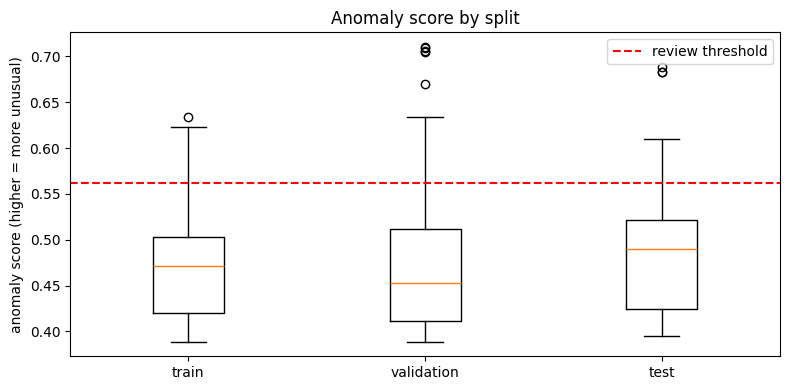

Labeled candidates per split:


decision,positive
split,
train,1



========== test  [HEADLINE]: 0 positive, 0 negative ==========
Skipped: need at least 5 of each class.

========== validation: 0 positive, 0 negative ==========
Skipped: need at least 5 of each class.

========== train  [in-sample — do not report]: 1 positive, 0 negative ==========
Skipped: need at least 5 of each class.

========== all labeled  [CI optimistic]: 1 positive, 0 negative ==========
Skipped: need at least 5 of each class.

Not enough labels yet. Label candidates in review.show(): mark each as positive or negative, prioritising the test day (20260920). Then rerun this cell.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: /content/xsm_recovery_pbfv15v8/xsm_hybrid_ml/runs/evaluation_20261009_133427


In [28]:
# =====================================================================
# XSM Isolation Forest — evaluation cells
# Paste each "CELL" block into a new Colab cell, at the END of your
# current notebook, in the same runtime (they reuse anomaly_model,
# demo_data, feature_columns, review_threshold, recovery, controls,
# review_folder, PROJECT).
#
# CELL A  – metrics from the simulation (works now; has ground truth)
# CELL B  – label-free checks on real data (works now)
# CELL C  – classification report + ROC-AUC + PR-AUC on REAL data
#           (only works after you label candidates positive/negative)
# CELL D  – save everything
# =====================================================================


# ---------------------------------------------------------------------
# CELL A — Precision / recall / F1 from the injected-burst simulation
# The simulation is the only place with known answers right now.
# ---------------------------------------------------------------------
import numpy as np
import pandas as pd
from IPython.display import display

sim = recovery.copy()
sim["precision"] = sim["recovered"] / (sim["recovered"] + sim["false_triggers"])
sim["recall"] = sim["recovered"] / sim["injected"]
sim["f1"] = 2 * sim["precision"] * sim["recall"] / (sim["precision"] + sim["recall"])
sim = sim.fillna(0.0)

print("SIMULATION METRICS (injected bursts = ground truth)")
display(sim[["stage", "strength", "injected", "recovered", "missed",
             "false_triggers", "precision", "recall", "f1"]].round(3))

overall = (sim.groupby("stage")[["injected", "recovered", "false_triggers"]]
              .sum())
overall["precision"] = overall["recovered"] / (overall["recovered"] + overall["false_triggers"])
overall["recall"] = overall["recovered"] / overall["injected"]
overall["f1"] = 2 * overall["precision"] * overall["recall"] / (overall["precision"] + overall["recall"])
print("\nAll strengths combined:")
display(overall.round(3))

ctrl = controls.copy()
print("\nFalse triggers on burst-free simulated signals:")
display(ctrl)

# What did the ML stage add over extraction alone?
ex = overall.loc["Extraction"]
ml = overall.loc["Extraction + ML"]
print(f"\nML filter removed {ex.false_triggers - ml.false_triggers:.0f} of "
      f"{ex.false_triggers:.0f} false triggers "
      f"and lost {ex.recovered - ml.recovered:.0f} of {ex.recovered:.0f} real bursts.")
print("Caution: 4 injections per strength is very few — treat these as rough.")


# ---------------------------------------------------------------------
# CELL B — Label-free checks on the real candidates
#   B1 score-distribution shift between days (KS test)
#   B2 ranking stability across random seeds
# ---------------------------------------------------------------------
from scipy.stats import ks_2samp, spearmanr
from sklearn.base import clone
import matplotlib.pyplot as plt

split = demo_data["split"]
score = demo_data["anomaly_score"]
train_mask = split.eq("train")

# B1 — do validation/test days look like the training days?
print("B1. Score distribution vs. train (KS test)")
rows = []
for s in ["validation", "test"]:
    stat, p = ks_2samp(score[train_mask], score[split.eq(s)])
    rows.append({"split": s, "ks_stat": stat, "p_value": p,
                 "flag_rate": demo_data.loc[split.eq(s), "high_priority"].mean()})
rows.insert(0, {"split": "train", "ks_stat": 0.0, "p_value": 1.0,
                "flag_rate": demo_data.loc[train_mask, "high_priority"].mean()})
display(pd.DataFrame(rows).round(4))
print("Train flag rate is ~5% by construction (95th-percentile threshold).\n"
      "Train scores are in-sample (the forest was fitted on them), so a small "
      "shift is expected even if the days are alike.\n"
      "Much higher rates on other days mean those days look different from "
      "the training days. That can come from real activity or from instrument state.\n")

# B2 — do the rankings stay the same if only the random seed changes?
print("B2. Ranking stability over 10 random seeds")
X_all = demo_data[feature_columns].apply(pd.to_numeric, errors="coerce") \
                                  .replace([np.inf, -np.inf], np.nan)
seed_scores = []
for seed in range(10):
    m = clone(anomaly_model).set_params(isolationforest__random_state=seed)
    m.fit(X_all.loc[train_mask])
    seed_scores.append(-m.score_samples(X_all))
seed_scores = np.array(seed_scores)

k = max(1, int(round(0.10 * len(demo_data))))          # top 10%
ref_top = set(np.argsort(-score.values)[:k])
rhos, jacc = [], []
for s in seed_scores:
    rhos.append(spearmanr(score.values, s).correlation)
    top = set(np.argsort(-s)[:k])
    jacc.append(len(ref_top & top) / len(ref_top | top))
print(f"Spearman rank correlation vs. your model: "
      f"mean {np.mean(rhos):.3f}, min {np.min(rhos):.3f}")
print(f"Top-{k} overlap (Jaccard):               "
      f"mean {np.mean(jacc):.3f}, min {np.min(jacc):.3f}")
print("If the ranking stays above ~0.9 across seeds, it is stable. "
      "Stable does not mean correct.")

fig_b, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([score[split.eq(s)] for s in ["train", "validation", "test"]])
ax.set_xticks([1, 2, 3], ["train", "validation", "test"])
ax.axhline(review_threshold, color="red", ls="--", label="review threshold")
ax.set(title="Anomaly score by split", ylabel="anomaly score (higher = more unusual)")
ax.legend(); plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
# CELL C — Real-data classification metrics (needs labels)
# Run it after you label candidates in review.show().
# Uses ONLY 'positive' (1) and 'negative' (0); uncertain/unreviewed are dropped.
# Isolation Forest never saw the labels, so every labeled candidate is a
# fair test. Report the TEST split as the headline number.
# ---------------------------------------------------------------------
from pathlib import Path
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

MIN_PER_CLASS = 5        # below this, the metrics carry no information
fig_c = None             # never save a curve left over from an earlier run

ann_path = Path(review_folder) / "review_baseline" / "annotations.csv"
ann = pd.read_csv(ann_path)
missing_cols = {"candidate_id", "decision"} - set(ann.columns)
if missing_cols:
    raise RuntimeError(f"annotations.csv has no {missing_cols} column. "
                       f"Its columns are: {list(ann.columns)}")

# Latest decision per reviewer (or per candidate if there is no reviewer column)
key = ["candidate_id", "reviewer"] if "reviewer" in ann.columns else ["candidate_id"]
ann = ann.drop_duplicates(key, keep="last")
ann = ann[ann["decision"].isin(["positive", "negative"])]

# If several reviewers labelled a candidate, keep it only when they agree
consensus = ann.groupby("candidate_id")["decision"].agg(
    lambda d: d.iloc[0] if d.nunique() == 1 else "conflict")
n_conflict = int((consensus == "conflict").sum())
if n_conflict:
    print(f"Dropped {n_conflict} candidates where reviewers disagree — "
          "resolve these before reporting.")
consensus = consensus[consensus != "conflict"].rename("decision").reset_index()

ev = demo_data.drop(columns=["decision"], errors="ignore") \
              .merge(consensus, on="candidate_id", how="inner")
ev["y_true"] = (ev["decision"] == "positive").astype(int)
ev["y_pred"] = ev["high_priority"].astype(int)

print("Labeled candidates per split:")
display(ev.groupby(["split", "decision"]).size().unstack(fill_value=0))


def evaluate(df, name, n_boot=2000, seed=0):
    n_pos, n_neg = int(df.y_true.sum()), int((1 - df.y_true).sum())
    print(f"\n========== {name}: {n_pos} positive, {n_neg} negative ==========")
    if n_pos < MIN_PER_CLASS or n_neg < MIN_PER_CLASS:
        print(f"Skipped: need at least {MIN_PER_CLASS} of each class.")
        return None

    y, s, p = df.y_true.values, df.anomaly_score.values, df.y_pred.values

    # Threshold-free ranking metrics (main ones for an anomaly score)
    auc = roc_auc_score(y, s)
    ap = average_precision_score(y, s)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if y[i].min() != y[i].max():
            boot.append(roc_auc_score(y[i], s[i]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"ROC-AUC : {auc:.3f}   (95% bootstrap CI {lo:.3f}–{hi:.3f}; 0.5 = random)")
    print(f"PR-AUC  : {ap:.3f}   (baseline = positive rate {y.mean():.3f})")

    # Precision at k: of the top-k ranked, how many are real bursts?
    order = np.argsort(-s)
    for kk in [5, 10, 20]:
        if kk <= len(y):
            print(f"Precision@{kk:<3}: {y[order[:kk]].mean():.3f}")

    # Threshold-based metrics at your review threshold
    print(f"\nAt review threshold {review_threshold:.4f}:")
    print(classification_report(y, p, labels=[0, 1],
                                target_names=["non-burst (0)", "burst (1)"],
                                zero_division=0))
    cm = confusion_matrix(y, p, labels=[0, 1])
    display(pd.DataFrame(cm, index=["true 0", "true 1"],
                         columns=["pred 0", "pred 1"]))
    return {"split": name, "n_pos": n_pos, "n_neg": n_neg, "roc_auc": auc,
            "roc_auc_ci_low": lo, "roc_auc_ci_high": hi, "pr_auc": ap,
            "prevalence": y.mean()}


# "train" is in-sample: the forest was fitted on those candidates' features.
# "all labeled" pools days; candidates from one day are correlated, so its
# bootstrap CI is too narrow. Report TEST (then validation) as the result.
results = []
for name, label in [("test", "test  [HEADLINE]"),
                    ("validation", "validation"),
                    ("train", "train  [in-sample — do not report]"),
                    (None, "all labeled  [CI optimistic]")]:
    subset = ev if name is None else ev[ev.split.eq(name)]
    r = evaluate(subset, label)
    if r: results.append(r)

if results:
    real_metrics = pd.DataFrame(results)
    display(real_metrics.round(3))

    # ROC and precision-recall curves on all labeled candidates
    if ev.y_true.nunique() == 2:
        fig_c, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
        fpr, tpr, _ = roc_curve(ev.y_true, ev.anomaly_score)
        a1.plot(fpr, tpr, label=f"AUC={roc_auc_score(ev.y_true, ev.anomaly_score):.3f}")
        a1.plot([0, 1], [0, 1], "k--", lw=0.8)
        a1.set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
        a1.legend()
        pr, rc, _ = precision_recall_curve(ev.y_true, ev.anomaly_score)
        a2.plot(rc, pr, label=f"AP={average_precision_score(ev.y_true, ev.anomaly_score):.3f}")
        a2.axhline(ev.y_true.mean(), color="k", ls="--", lw=0.8, label="random")
        a2.set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision")
        a2.legend(); plt.tight_layout(); plt.show()
else:
    real_metrics = None
    print("\nNot enough labels yet. Label candidates in review.show(): mark "
          "each as positive or negative, prioritising the test day (20260920). "
          "Then rerun this cell.")


# ---------------------------------------------------------------------
# CELL D — Save evaluation outputs and download
# ---------------------------------------------------------------------
from datetime import datetime
import shutil, json
from google.colab import files

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
eval_dir = Path(PROJECT) / "runs" / f"evaluation_{stamp}"
eval_dir.mkdir(parents=True)

sim.to_csv(eval_dir / "simulation_metrics.csv", index=False)
overall.to_csv(eval_dir / "simulation_metrics_overall.csv")
pd.DataFrame(rows).to_csv(eval_dir / "split_shift.csv", index=False)
(eval_dir / "seed_stability.json").write_text(json.dumps({
    "spearman_mean": float(np.mean(rhos)), "spearman_min": float(np.min(rhos)),
    "topk": k, "jaccard_mean": float(np.mean(jacc)), "jaccard_min": float(np.min(jacc)),
}, indent=2))
fig_b.savefig(eval_dir / "scores_by_split.png", dpi=150, bbox_inches="tight")
if real_metrics is not None:
    real_metrics.to_csv(eval_dir / "real_data_metrics.csv", index=False)
    ev.to_csv(eval_dir / "labeled_candidates_scored.csv", index=False)
    if fig_c is not None:
        fig_c.savefig(eval_dir / "roc_pr_curves.png", dpi=150, bbox_inches="tight")

zip_path = shutil.make_archive(f"/content/XSM_evaluation_{stamp}", "zip",
                               root_dir=str(eval_dir.parent), base_dir=eval_dir.name)
files.download(zip_path)
print("Saved:", eval_dir)

In [2]:
from pathlib import Path
from google.colab import files
import sys, io, zipfile

required = [
    "PROJECT", "demo_data", "anomaly_model",
    "feature_columns", "review_threshold"
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier Isolation Forest setup/training cells first. "
        "Missing: " + ", ".join(missing)
    )

uploaded = files.upload()
installed = False

for name, data in uploaded.items():
    if name.lower().endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            if "xsm_classifier_demo.py" in archive.namelist():
                destination = Path(PROJECT) / "xsm_classifier_demo.py"
                destination.write_bytes(
                    archive.read("xsm_classifier_demo.py")
                )
                installed = True

if not installed:
    raise RuntimeError("Select XSM_Classifier_Comparison.zip.")

sys.path.insert(0, str(Path(PROJECT) / "src"))
sys.path.insert(0, str(PROJECT))

from xsm_classifier_demo import run_experiment

print("Ready. Run Cell 2.")

RuntimeError: Run the earlier Isolation Forest setup/training cells first. Missing: PROJECT, demo_data, anomaly_model, feature_columns, review_threshold

In [3]:
from pathlib import Path
from google.colab import files
import sys, io, zipfile

required = [
    "PROJECT", "demo_data", "anomaly_model",
    "feature_columns", "review_threshold"
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier Isolation Forest setup/training cells first. "
        "Missing: " + ", ".join(missing)
    )

uploaded = files.upload()
installed = False

for name, data in uploaded.items():
    if name.lower().endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            if "xsm_classifier_demo.py" in archive.namelist():
                destination = Path(PROJECT) / "xsm_classifier_demo.py"
                destination.write_bytes(
                    archive.read("xsm_classifier_demo.py")
                )
                installed = True

if not installed:
    raise RuntimeError("Select XSM_Classifier_Comparison.zip.")

sys.path.insert(0, str(Path(PROJECT) / "src"))
sys.path.insert(0, str(PROJECT))

from xsm_classifier_demo import run_experiment

print("Ready. Run Cell 2.")

RuntimeError: Run the earlier Isolation Forest setup/training cells first. Missing: PROJECT, demo_data, anomaly_model, feature_columns, review_threshold

In [4]:
from google.colab import files
from pathlib import Path
import io, zipfile, tempfile

uploaded = files.upload()

recovery_root = Path(
    tempfile.mkdtemp(prefix="xsm_restored_", dir="/content")
)

for name, data in uploaded.items():
    if name.lower().endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            archive.extractall(recovery_root)

projects = [
    path.parent
    for path in recovery_root.rglob("run_xsm.py")
    if (path.parent / "src" / "xsm_burst").is_dir()
]

if len(projects) != 1:
    raise RuntimeError(
        "Upload one full XSM_work_backup ZIP containing your project."
    )

PROJECT = projects[0]
print("Project restored:", PROJECT)

Saving XSM_work_backup_20261009_112857.zip to XSM_work_backup_20261009_112857.zip
Project restored: /content/xsm_restored_peeqedon/xsm_hybrid_ml


In [5]:
import sys, subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "-r", str(PROJECT / "requirements-tested.txt")
])

sys.path.insert(0, str(PROJECT / "src"))

import numpy as np
import pandas as pd
from xsm_burst.features import FEATURES
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

csv_paths = list(
    PROJECT.glob(
        "runs/batch_*/training_review_*/training_candidates.csv"
    )
)

if len(csv_paths) != 1:
    print("Candidate tables found:")
    for path in csv_paths:
        print(path)
    raise RuntimeError(
        "Expected one saved training_candidates.csv. "
        "Send this printed output if several or none are found."
    )

candidate_path = csv_paths[0]
review_folder = candidate_path.parent
BATCH_RUN = review_folder.parent

demo_data = pd.read_csv(
    candidate_path, dtype={"group_id": str}
)

split_plan = {
    "20260716": "train",
    "20260913": "train",
    "20260916": "train",
    "20260917": "train",
    "20260919": "validation",
    "20260920": "test",
}

demo_data["split"] = demo_data["group_id"].map(split_plan)

if demo_data["split"].isna().any():
    raise ValueError("An observation date is missing from the split plan.")

X = demo_data[FEATURES].apply(
    pd.to_numeric, errors="raise"
).replace([np.inf, -np.inf], np.nan)

train_mask = demo_data["split"].eq("train")

feature_columns = X.columns[
    X.loc[train_mask].notna().any()
].tolist()

X = X[feature_columns]

anomaly_model = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination="auto",
        random_state=42,
        n_jobs=2
    )
)

anomaly_model.fit(X.loc[train_mask])

review_threshold = float(np.quantile(
    -anomaly_model.score_samples(X.loc[train_mask]),
    0.95
))

print("Recovery complete.")
print(demo_data["split"].value_counts())
print("Now rerun Cell 1 of the classifier comparison.")

ImportError: cannot import name '_slice' from 'numpy._core.umath' (/usr/local/lib/python3.13/dist-packages/numpy/_core/umath.py)

In [6]:
from pathlib import Path

Path("/content/xsm_project_path.txt").write_text(str(PROJECT))
print("Project path saved:", PROJECT)

Project path saved: /content/xsm_restored_peeqedon/xsm_hybrid_ml


In [1]:
from pathlib import Path
import sys

saved_path = Path("/content/xsm_project_path.txt")

if not saved_path.exists():
    raise RuntimeError(
        "The saved path is missing. Restore your project backup first."
    )

PROJECT = Path(saved_path.read_text().strip())

if not (PROJECT / "src" / "xsm_burst").is_dir():
    raise RuntimeError("Project files are missing. Restore your backup.")

sys.path.insert(0, str(PROJECT / "src"))

import numpy as np
import pandas as pd
from xsm_burst.features import FEATURES
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

print("NumPy imported successfully:", np.__version__)

csv_paths = list(
    PROJECT.glob(
        "runs/batch_*/training_review_*/training_candidates.csv"
    )
)

if len(csv_paths) != 1:
    print("Candidate tables found:")
    for path in csv_paths:
        print(path)
    raise RuntimeError(
        "Expected one candidate table. Share the printed paths."
    )

candidate_path = csv_paths[0]
review_folder = candidate_path.parent
BATCH_RUN = review_folder.parent

demo_data = pd.read_csv(
    candidate_path, dtype={"group_id": str}
)

split_plan = {
    "20260716": "train",
    "20260913": "train",
    "20260916": "train",
    "20260917": "train",
    "20260919": "validation",
    "20260920": "test",
}

demo_data["split"] = demo_data["group_id"].map(split_plan)

if demo_data["split"].isna().any():
    raise ValueError("An observation date is missing from the split plan.")

X = demo_data[FEATURES].apply(
    pd.to_numeric, errors="raise"
).replace([np.inf, -np.inf], np.nan)

train_mask = demo_data["split"].eq("train")

feature_columns = X.columns[
    X.loc[train_mask].notna().any()
].tolist()

X = X[feature_columns]

anomaly_model = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination="auto",
        random_state=42,
        n_jobs=2
    )
)

anomaly_model.fit(X.loc[train_mask])

review_threshold = float(np.quantile(
    -anomaly_model.score_samples(X.loc[train_mask]),
    0.95
))

print("Recovery complete.")
print(demo_data["split"].value_counts())
print("Ready for the classifier-comparison cells.")

NumPy imported successfully: 2.3.5
Recovery complete.
split
train         130
validation     96
test           54
Name: count, dtype: int64
Ready for the classifier-comparison cells.


In [2]:
from pathlib import Path
from google.colab import files
import sys, io, zipfile

required = [
    "PROJECT", "demo_data", "anomaly_model",
    "feature_columns", "review_threshold"
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier Isolation Forest setup/training cells first. "
        "Missing: " + ", ".join(missing)
    )

uploaded = files.upload()
installed = False

for name, data in uploaded.items():
    if name.lower().endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            if "xsm_classifier_demo.py" in archive.namelist():
                destination = Path(PROJECT) / "xsm_classifier_demo.py"
                destination.write_bytes(
                    archive.read("xsm_classifier_demo.py")
                )
                installed = True

if not installed:
    raise RuntimeError("Select XSM_Classifier_Comparison.zip.")

sys.path.insert(0, str(Path(PROJECT) / "src"))
sys.path.insert(0, str(PROJECT))

from xsm_classifier_demo import run_experiment

print("Ready. Run Cell 2.")

Saving XSM_Classifier_Comparison.zip to XSM_Classifier_Comparison.zip
Ready. Run Cell 2.


In [3]:
comparison_folder = (
    Path(PROJECT) / "runs" / "synthetic_classifier_v1"
)

if (comparison_folder / "report.json").exists():
    print("Completed results already exist. Continue to Cell 3.")
else:
    comparison_folder = run_experiment(
        frame=demo_data,
        isolation_model=anomaly_model,
        isolation_columns=feature_columns,
        isolation_threshold=review_threshold,
        output_dir=comparison_folder
    )

train: 6/96 simulated observations
train: 12/96 simulated observations
train: 18/96 simulated observations
train: 24/96 simulated observations
train: 30/96 simulated observations
train: 36/96 simulated observations
train: 42/96 simulated observations
train: 48/96 simulated observations
train: 54/96 simulated observations
train: 60/96 simulated observations
train: 66/96 simulated observations
train: 72/96 simulated observations
train: 78/96 simulated observations
train: 84/96 simulated observations
train: 90/96 simulated observations
train: 96/96 simulated observations
validation: 6/36 simulated observations
validation: 12/36 simulated observations
validation: 18/36 simulated observations
validation: 24/36 simulated observations
validation: 30/36 simulated observations
validation: 36/36 simulated observations
Fitting Random Forest and XGBoost on simulation labels...
Frozen selection: XGBoost. Now generating untouched test simulations.
test: 6/60 simulated observations
test: 12/60 simula

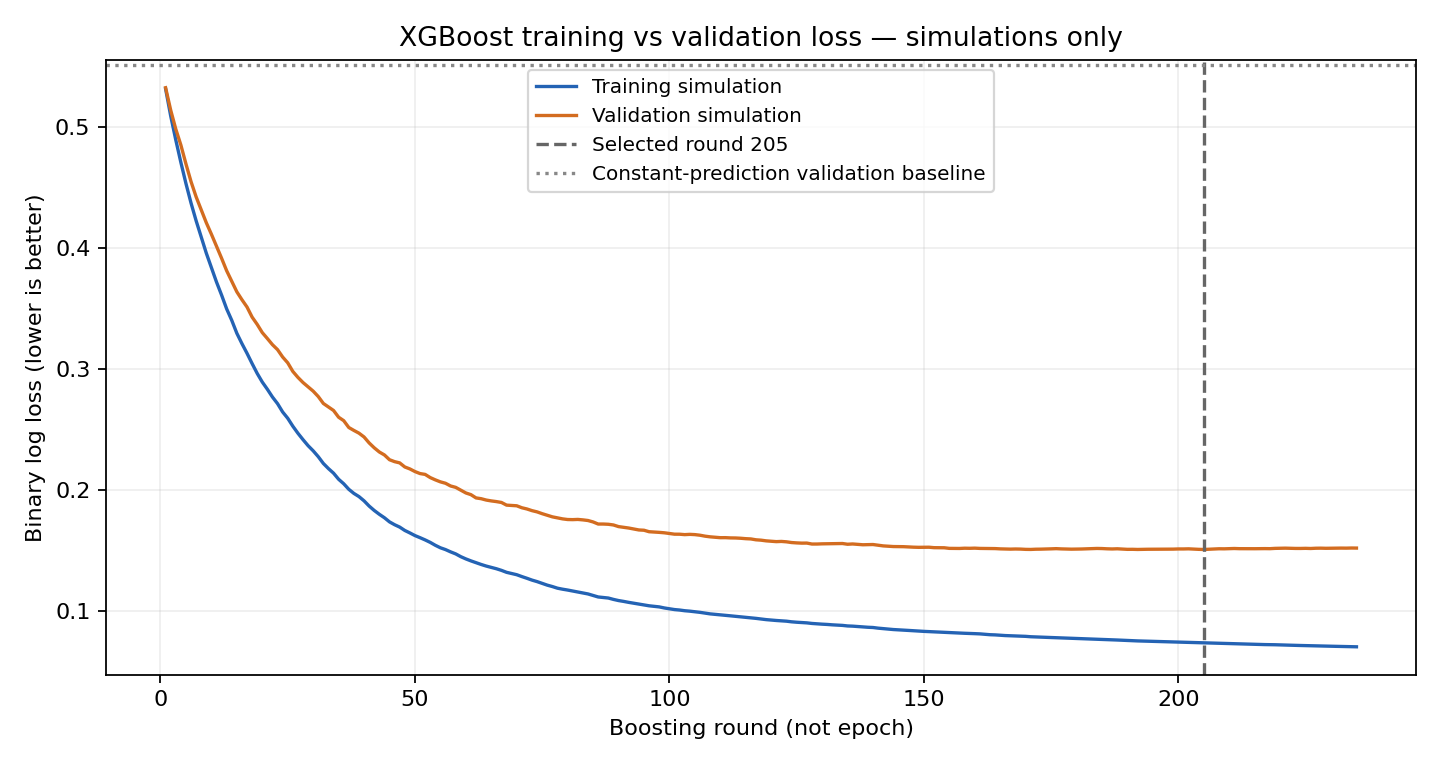

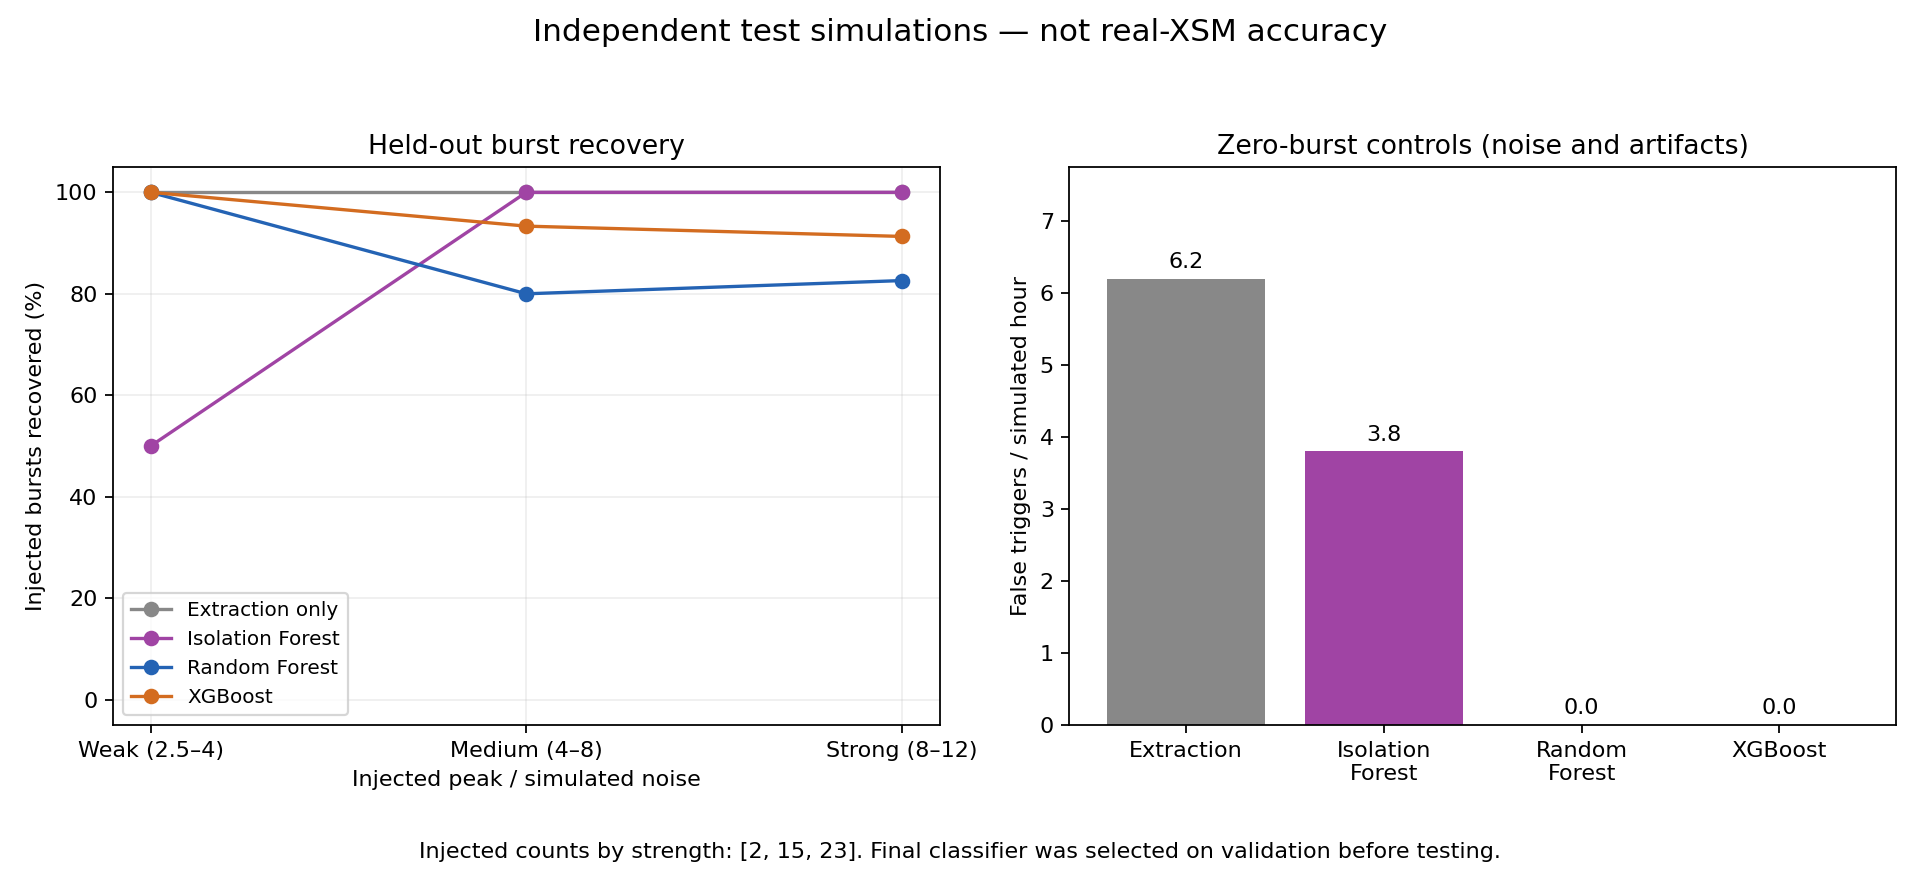

,model,selected_on_validation,recovered,missed,false_triggers,event_precision,event_recall
0,Extraction only,False,40,0,122,0.246914,1.000
1,Isolation Forest,False,39,1,67,0.367925,0.975
2,Random Forest,False,33,7,1,0.970588,0.825
3,XGBoost,True,37,3,2,0.948718,0.925


Selected model: XGBoost
Selected XGBoost round: 205


In [4]:
from IPython.display import display, Image
import pandas as pd
import json

display(Image(
    filename=str(
        comparison_folder / "training_validation_loss.png"
    )
))

display(Image(
    filename=str(
        comparison_folder / "heldout_comparison.png"
    )
))

results = pd.read_csv(
    comparison_folder / "test_comparison.csv"
)

display(results[[
    "model",
    "selected_on_validation",
    "recovered",
    "missed",
    "false_triggers",
    "event_precision",
    "event_recall"
]])

report = json.loads(
    (comparison_folder / "report.json").read_text()
)

print("Selected model:", report["selected_model"])
print("Selected XGBoost round:", report["best_xgboost_round"])

In [5]:
import shutil
from google.colab import files

result_zip = shutil.make_archive(
    "/content/XSM_classifier_results",
    "zip",
    root_dir=str(comparison_folder.parent),
    base_dir=comparison_folder.name
)

files.download(result_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

if "PROJECT" not in globals():
    raise RuntimeError("Restore PROJECT using the recovery cell first.")

comparison_folder = (
    Path(PROJECT) / "runs" / "synthetic_classifier_v1"
)

required_files = [
    "report.json",
    "protocol.json",
    "test_predictions.csv",
    "test/injected_truth.csv",
    "test/observations.csv"
]

missing = [
    name for name in required_files
    if not (comparison_folder / name).exists()
]

if missing:
    raise RuntimeError(
        "Finish classifier training/testing first. Missing: "
        + ", ".join(missing)
    )

sys.path.insert(0, str(Path(PROJECT) / "src"))
from xsm_burst.evaluation import match_events

report = json.loads(
    (comparison_folder / "report.json").read_text()
)
protocol = json.loads(
    (comparison_folder / "protocol.json").read_text()
)

predictions = pd.read_csv(
    comparison_folder / "test_predictions.csv"
)
truth = pd.read_csv(
    comparison_folder / "test/injected_truth.csv"
)
observations = pd.read_csv(
    comparison_folder / "test/observations.csv"
)

# Observations containing no injected bursts.
null_observations = observations[
    observations["injected"].eq(0)
]
null_hours = (
    null_observations["processed_seconds"].sum() / 3600
)

if null_hours <= 0:
    raise ValueError("No zero-burst control exposure was found.")

rules = {
    "Extraction only": (None, None),
    "Isolation Forest": (
        "isolation_forest_score",
        protocol["isolation_threshold"]
    ),
    "Random Forest": (
        "random_forest_score",
        report["threshold"]
    ),
    "XGBoost": (
        "xgboost_score",
        report["threshold"]
    )
}

rows = []
matches_by_model = {}

for name, (score_column, threshold) in rules.items():
    if score_column is None:
        accepted = predictions
    else:
        if not np.isfinite(predictions[score_column]).all():
            raise ValueError(f"Invalid scores for {name}.")
        accepted = predictions[
            predictions[score_column] >= threshold
        ]

    matched = match_events(
        accepted,
        truth,
        tolerance_s=float(protocol["matching_tolerance_s"])
    )
    matches_by_model[name] = matched

    tp = matched["tp"]
    fp = matched["fp"]
    fn = matched["fn"]

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0

    null_false = int(
        accepted["group_id"].isin(
            null_observations["group_id"]
        ).sum()
    )

    rows.append({
        "Model": name,
        "Selected on validation": name == report["selected_model"],
        "Recovered bursts": tp,
        "Missed bursts": fn,
        "False detections": fp,
        "Precision (%)": 100 * precision,
        "Recall (%)": 100 * recall,
        "F1 (%)": 100 * f1,
        "Control false triggers/hour": null_false / null_hours
    })

final_summary = pd.DataFrame(rows)

print("FINAL EVALUATION — SIMULATIONS ONLY")
print("Selected model:", report["selected_model"])
print("Injected test bursts:", len(truth))
print("Zero-burst control hours:", round(null_hours, 2))

display(final_summary.round(2))

FINAL EVALUATION — SIMULATIONS ONLY
Selected model: XGBoost
Injected test bursts: 40
Zero-burst control hours: 5.0


,Model,Selected on validation,Recovered bursts,Missed bursts,False detections,Precision (%),Recall (%),F1 (%),Control false triggers/hour
0,Extraction only,False,40,0,122,24.69,100.0,39.60,6.2
1,Isolation Forest,False,39,1,67,36.79,97.5,53.42,3.8
2,Random Forest,False,33,7,1,97.06,82.5,89.19,0.0
3,XGBoost,True,37,3,2,94.87,92.5,93.67,0.0


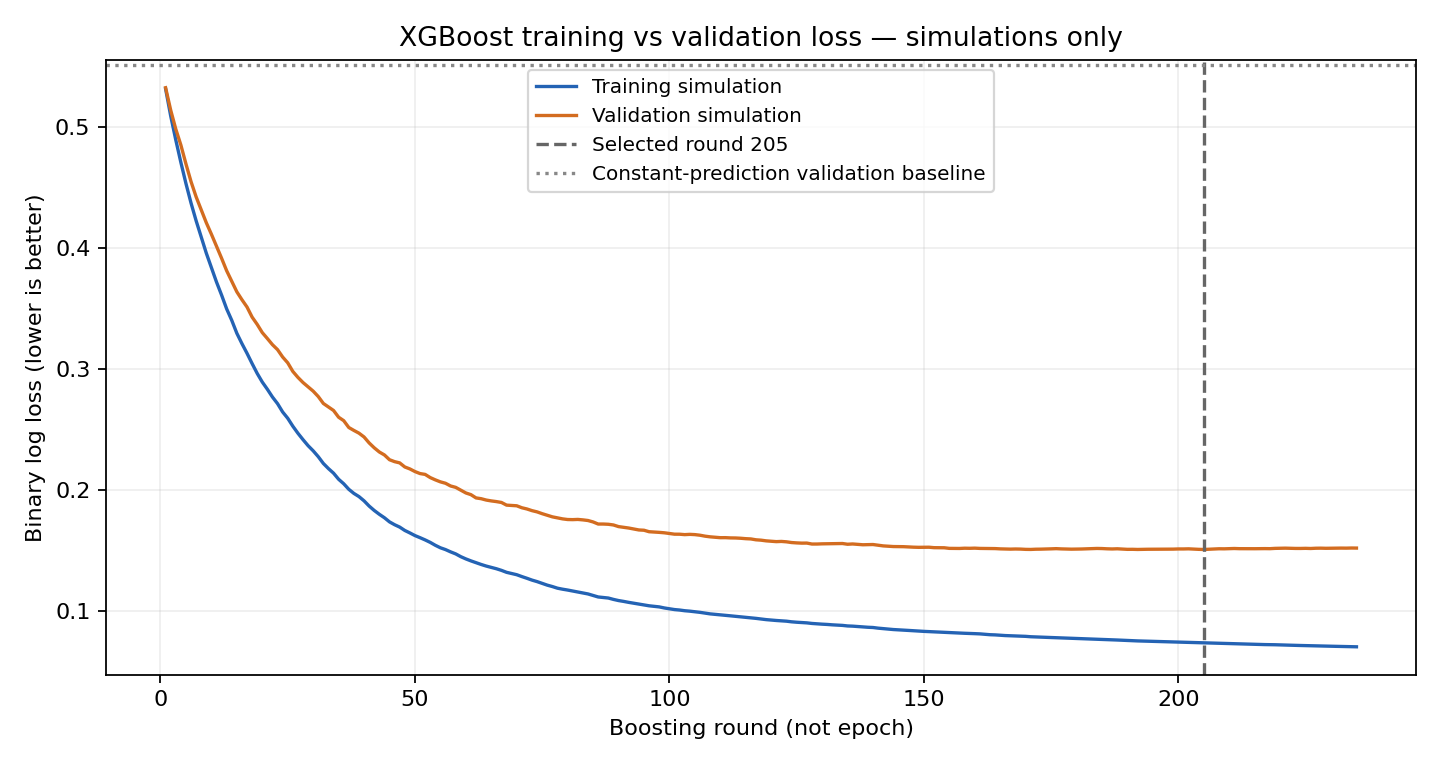

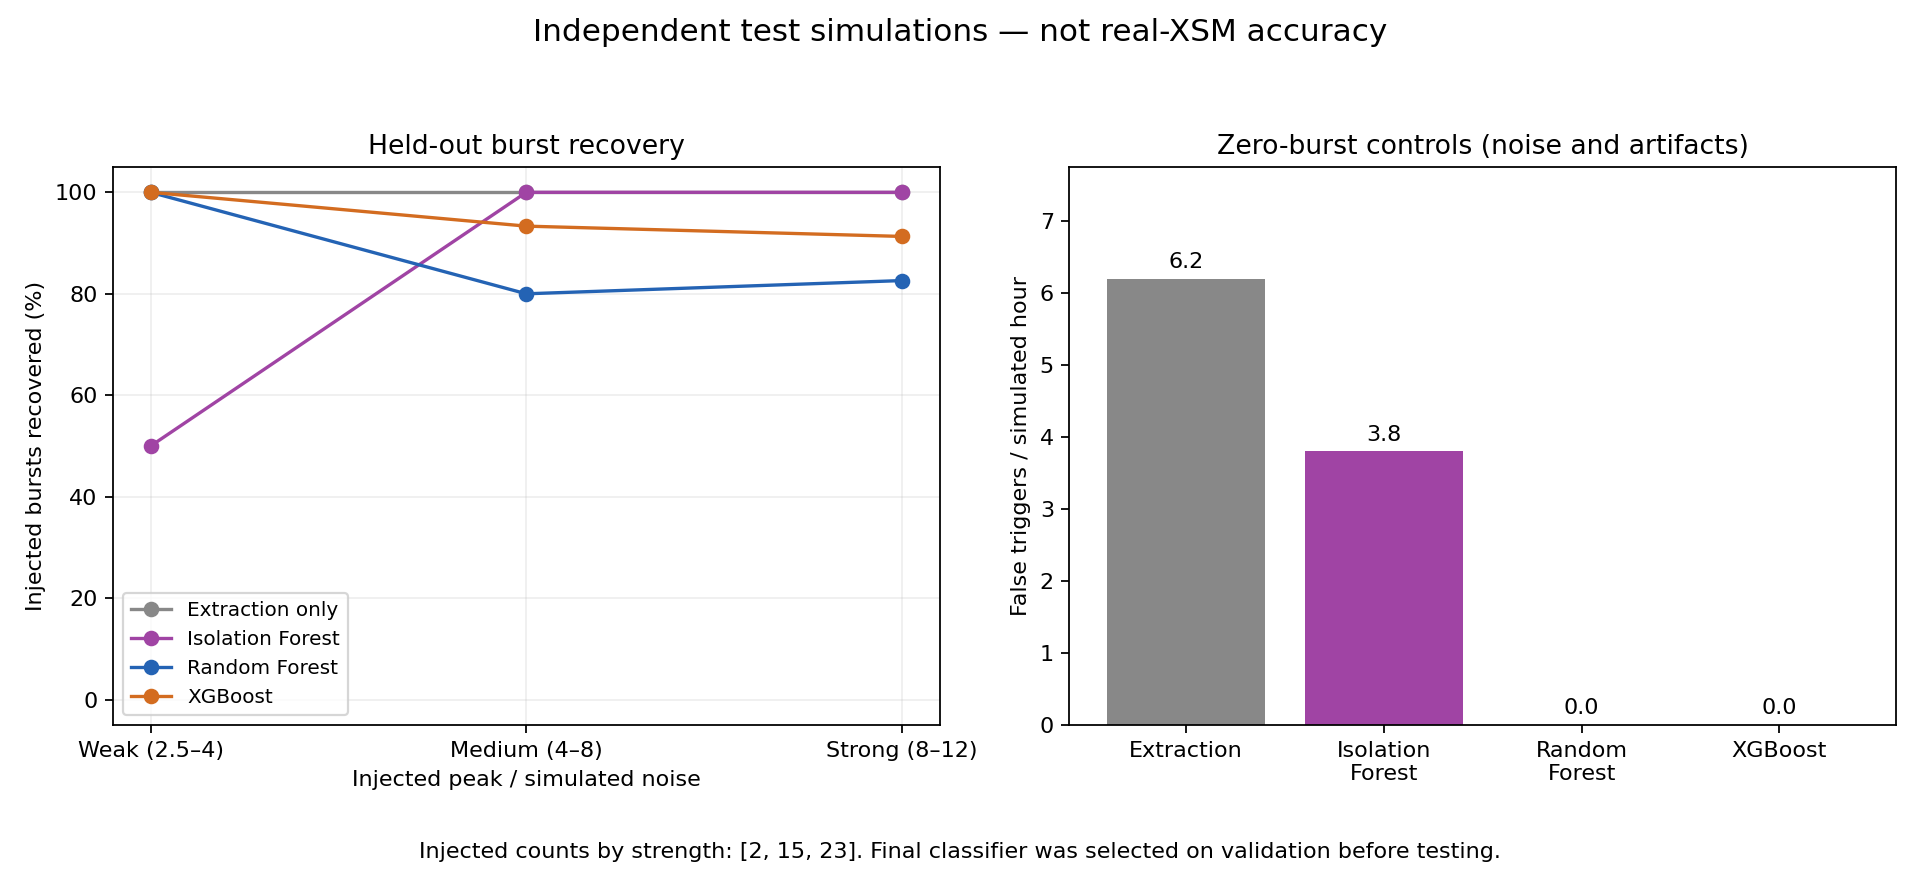

SELECTED MODEL: XGBoost


,Burst strength,Injected,Recovered,Missed,Recovery (%)
0,Weak (2.5–4),2,2,0,100.00
1,Medium (4–8),15,14,1,93.33
2,Strong (8–12),23,21,2,91.30


Weak-burst results are based on only 2 examples.

Interpretation:
• Higher precision, recall, and F1 are better.
• Fewer false triggers are better.
• Read recovery percentages together with their sample counts.
• Zero observed false triggers does not prove a zero false-alarm rate.
• These results do not establish real-ISRO accuracy.


In [7]:
display(Image(filename=str(
    comparison_folder / "training_validation_loss.png"
)))

display(Image(filename=str(
    comparison_folder / "heldout_comparison.png"
)))

selected_model = report["selected_model"]

# Reference-event indices successfully matched by the selected model.
recovered_indices = {
    reference_index
    for _, reference_index
    in matches_by_model[selected_model]["pairs"]
}

strength_rows = []

for band in [
    "Weak (2.5–4)",
    "Medium (4–8)",
    "Strong (8–12)"
]:
    subset = truth[truth["strength_band"].eq(band)]
    total = len(subset)
    recovered = len(set(subset.index) & recovered_indices)

    strength_rows.append({
        "Burst strength": band,
        "Injected": total,
        "Recovered": recovered,
        "Missed": total - recovered,
        "Recovery (%)": (
            100 * recovered / total if total else np.nan
        )
    })

strength_summary = pd.DataFrame(strength_rows)

print("SELECTED MODEL:", selected_model)
display(strength_summary.round(2))

weak_count = int(strength_summary.iloc[0]["Injected"])
print(f"Weak-burst results are based on only {weak_count} examples.")

print(
    "\nInterpretation:"
    "\n• Higher precision, recall, and F1 are better."
    "\n• Fewer false triggers are better."
    "\n• Read recovery percentages together with their sample counts."
    "\n• Zero observed false triggers does not prove a zero false-alarm rate."
    "\n• These results do not establish real-ISRO accuracy."
)

## Next steps

The supplied observation produces 2 unconfirmed candidates with the tested versions. Fewer candidates is not proof of higher scientific accuracy. Review all interval plots as well as candidate plots. Keep uncertain labels blank. Obtain reviewed examples of both burst and non-burst observations across independent observing periods before supervised training. Do not train on this single day or reuse version-0.1 candidate tables/weights with this pipeline.

For additional days, place matching `.lc` and `.gti` files under a new project data directory and point the runner there. Review energy selection, calibration and instrument-state consistency before combining files.

If a runtime resets, upload this notebook again if needed and run from cell 1 with your latest downloaded backup ZIP. The notebook itself does not store runtime files.
